In [ ]:
import pandas as pd

df = pd.read_csv("/root/.cache/kagglehub/datasets/usdot/flight-delays/versions/1/flights.csv")

/tmp/ipykernel_5890/3125724354.py:3: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/root/.cache/kagglehub/datasets/usdot/flight-delays/versions/1/flights.csv")


In [ ]:
df['Delayed'] = (df['ARRIVAL_DELAY'] >= 15).astype(int)

In [ ]:
df_small = df.sample(200000, random_state=42)

In [ ]:
features = ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
            'DEPARTURE_TIME', 'DISTANCE']

X = df_small[features]
y = df_small['Delayed']

In [ ]:
X = X.dropna()
y = y.loc[X.index]

In [ ]:
X['AIRLINE'] = X['AIRLINE'].astype(str)
X['ORIGIN_AIRPORT'] = X['ORIGIN_AIRPORT'].astype(str)
X['DESTINATION_AIRPORT'] = X['DESTINATION_AIRPORT'].astype(str)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

categorical = ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']
numeric = ['DEPARTURE_TIME', 'DISTANCE']

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
        ('num', 'passthrough', numeric)
    ]
)

model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('tree', DecisionTreeClassifier())
])

model.fit(X_train, y_train)
preds = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, preds)

0.7778369603814742

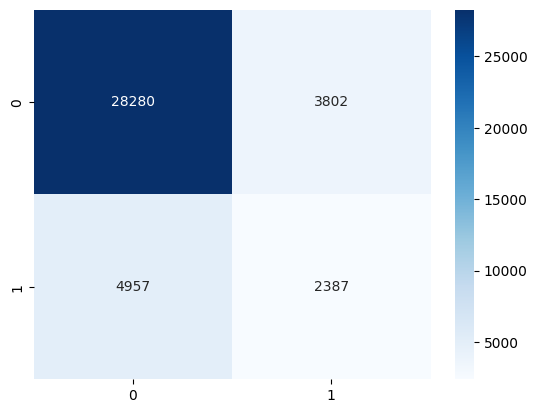

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, preds)
accuracy

0.7778369603814742

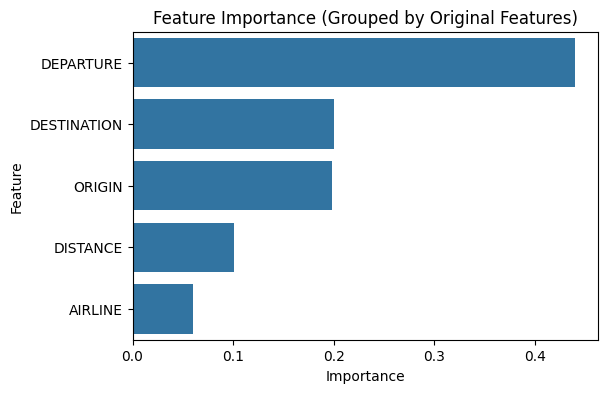

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get raw importances from the tree
importances = model.named_steps['tree'].feature_importances_

# Get one-hot encoded feature names
ohe = model.named_steps['preprocess'].named_transformers_['cat']
ohe_features = ohe.get_feature_names_out(['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT'])

# Combine with numeric features
all_features = list(ohe_features) + ['DEPARTURE_TIME', 'DISTANCE']

# Build a DataFrame
fi = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
})

# Group back to original 5 features
fi['BaseFeature'] = fi['Feature'].apply(lambda x: x.split('_')[0])

grouped = fi.groupby('BaseFeature')['Importance'].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(6,4))
sns.barplot(x=grouped.values, y=grouped.index)
plt.title("Feature Importance (Grouped by Original Features)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()